# Process Annotated Data
Translate Label Studio JSON files to a format for ML

In [1]:
import json
import ast
from datetime import datetime
from collections import defaultdict
from typing import Any, Dict

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from common.paths import RAW, PROCESSED
from utils.utils import analyze_category_distribution_from_dict, plot_cooccurrence_heatmap

In [3]:
class Config:
    ANNOTATED_DATA_PATH = RAW / "annotations" / "annotated-gold-standard.json"
    TAXONOMY_PATH = PROCESSED / "taxonomy_autogen_v2.csv"

    OUTPUT_PATH = PROCESSED / "gold_standard.json"
    OUTPUT_PATH_DOC_LEVEL = PROCESSED / "gold_standard_doc_level.json"
    TAXONOMY_V3_PATH = PROCESSED / "taxonomy_autogen_v3.csv"

    RANDOM_STATE = 42
    ENTITY_LABELS = {"Person_Name", "Person_Role", "Person_Pronoun"}
    CAT_LABELS = []


## Import Data

In [4]:
with open(Config.ANNOTATED_DATA_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

len(data)

2000

In [5]:
taxonomy = pd.read_csv(Config.TAXONOMY_PATH)
taxonomy.head(5)

,high_level_category,category_description,values_hint,cat_label,regex
0,Care,Care experienced,"['Care leaver', 'Care experienced (under 25)']",care_care_experienced,\bcare experienced\b|\bcare leaver\b|\baged ou...
1,Care,Care setting,"['Fostered', 'Social care']",care_care_setting,\bfostered\b|\bfoster care\b|\bfoster placemen...
2,Care,Has caring responsibility,"['Formal', 'Informal']",care_has_caring_responsibility,\bformal carer\b|\bregistered carer\b|\bcarer....
3,Care,Social care involvement,"['Adult Social Care', ""Children's Social Care""]",care_social_care_involvement,\bsocial care\b|\bcare package\b|\bcare plan\b...
4,Cautions,ASBO or injunction obtained,"['ASBO', 'Injunction']",cautions_asbo_or_injunction_obtained,\bASBO\b|\binjunction\b|\bcivil injunction\b|\...


## Format

Strip out Label Studio Metadata, make sure spans are aligned with words.

In [6]:
Config.CAT_LABELS = set(taxonomy.cat_label.values.tolist())

In [7]:
def clean_span(text: str, start: int, end: int):
    """
    Validates and cleans Label Studio character offsets.
    Expands span boundaries if they split a word.
    """
    if start < 0 or end > len(text) or start >= end:
        return None

    # Expand backwards if we are in the middle of a word
    while start > 0 and text[start - 1].isalnum():
        start -= 1

    # Expand forwards if we are in the middle of a word
    while end < len(text) and text[end].isalnum():
        end += 1

    span_text = text[start:end]

    # Remove accidental whitespace
    cleaned = span_text.strip()

    if not cleaned:
        return None

    leading_whitespace = len(span_text) - len(span_text.lstrip())

    new_start = start + leading_whitespace
    new_end = new_start + len(cleaned)

    return {
        "text": cleaned,
        "start": new_start,
        "end": new_end
    }

In [8]:
def extract_annotations(task: Dict[str, Any]) -> Dict[str, Any] | None:
    '''
    Extract annotations from label studio. Strip out irrelevant metadata, output in a clean format.
    Output format: {id: uuid (note id), label_studio_id: int, annotation_date: datetime, text: str (note text), needs: list(dict), persons: list(dict), relations: list(dict)}
    '''
    
    id = task["data"]["id"]
    text = task["data"]["note_content"]

    # 2. Get annotations from array
    task_annotations = task["annotations"]
    if len(task_annotations) == 0:
        print(f"Note with id {id} has no annotations.")
        return None
    else:
        # Fix accidental duplicated annotations - choose earliest one
        annotation = min(task_annotations, key=lambda x: datetime.strptime(x["created_at"], "%Y-%m-%dT%H:%M:%S.%fZ"))
    
    annotation_date = datetime.strptime(annotation["created_at"], "%Y-%m-%dT%H:%M:%S.%fZ")
    labels = annotation["result"]

    # 3. Handle annotations
    needs = []
    persons = []
    relations = []
    seen_ids = set()

    # 3.1. Handle text labels first
    for l in labels:
        if l["type"] != "labels":
            continue

        entity_id = l["id"]
        label = l["value"]["labels"][0]
        original_start = l["value"]["start"]
        original_end = l["value"]["end"]

        # Check span is correct 
        span = clean_span(text, original_start, original_end)
        if span is None:
            print(f"Skipping invalid span. Entity ID: {entity_id}, Note ID: {id}")
            continue

        clean_text = span["text"]
        new_start = span["start"]
        new_end = span["end"]

        # Save to seen_ids and relevant list
        if entity_id not in seen_ids:
            seen_ids.add(entity_id)
        
        item = {"id": entity_id, "text": clean_text, "start": new_start, "end": new_end, "label": label}

        # Needs
        if l["from_name"] == "need_labels" and label in Config.CAT_LABELS:
            needs.append(item)
        # Persons
        elif l["from_name"] == "entity_labels" and label in Config.ENTITY_LABELS:
            persons.append(item)
        else:
            print(f"Skipping unknown label: type: '{l['from_name']}', label: '{label}' in note '{id}'")

    # 3.2. Handle relations second (make sure all IDs exist)
    for l in labels:
        if l["type"] != "relation":
            continue

        from_id = l["from_id"]
        to_id = l["to_id"]

        if from_id in seen_ids and to_id in seen_ids:
            relations.append({"from": from_id, "to": to_id})
        else:
            print(f"Skipping relation between unknown id(s): from: '{from_id}', to: '{to_id}' in note '{id}'")

    return {
        "id": id,
        "label_studio_id": task['id'],
        "annotation_date": annotation_date,
        "text": text,
        "needs": needs,
        "persons": persons,
        "relations": relations,
    }

In [9]:
records = [extract_annotations(task) for task in data]

In [10]:
records[1]

{'id': '685524bb-94d4-4f08-8669-0e78df744c0c',
 'label_studio_id': 28101,
 'annotation_date': datetime.datetime(2026, 5, 19, 15, 18, 59, 455700),
 'text': '[Category: tenureManagement] Welfare check and tenancy audit completed I visited the tenant in his property following his request for me to come over and assess the toilet in his property. I used the opportunity to complete a tenancy audit and I observed that he is a hoarder with so many items in nearly all the rooms. The toilet seat has broken and the toilet is as dark as charcoal.',
 'needs': [{'id': '3aefb716',
   'text': 'hoarder',
   'start': 268,
   'end': 275,
   'label': 'housing_conditions_hoarding'},
  {'id': '99751da7',
   'text': 'so many items in nearly all the rooms',
   'start': 281,
   'end': 318,
   'label': 'housing_conditions_hoarding'},
  {'id': '354b3b37',
   'text': 'toilet seat has broken',
   'start': 324,
   'end': 346,
   'label': 'property_level_disrepair_damp_mould'},
  {'id': 'c8515bee',
   'text': 'toil

## Find Duplicates (on note text), ensure annotations are identical

In [11]:
# Group records by exact text match
grouped = defaultdict(list)
for record in records:
    grouped[record["text"]].append(record)
len(grouped)

1908

In [12]:
for note_content, duplicates in grouped.items():
    if len(duplicates) == 1:
        continue
    
    # If duplicated, choose latest annotation
    duplicates.sort(key=lambda x: x['annotation_date'], reverse=True)
    newest = duplicates[0]

    for record in duplicates:
        if (
            record["needs"] != newest["needs"]
            or record["persons"] != newest["persons"]
            or record["relations"] != newest["relations"]
        ):
            print(f"Replacing annotations for note '{record['id']}' with note '{newest['id']}'.")
            record['needs'] = newest['needs']
            record['persons'] = newest['persons']
            record['relations'] = newest['relations']

Replacing annotations for note 'b7b3fb41-80b7-4d97-b8f4-0e0a7156ab79' with note 'b30cc085-4908-4612-9050-f49b6d7d2f04'.
Replacing annotations for note '44683a11-6a65-4a2f-ae9e-8296fc794d5b' with note '749ba836-2c77-4723-b9f5-574eaa2c70ab'.
Replacing annotations for note '169c4fff-f124-416b-ab22-f0caaa2f527a' with note 'd5a9d2e5-4139-42d2-8bea-972e04cafe27'.
Replacing annotations for note '5fd5e463-dc99-4704-8c6d-f4f6c3a73bbf' with note '7ea1211f-f951-41a5-a48b-7c73595796ba'.
Replacing annotations for note '7b13a8be-d9c1-4622-9b7b-0ae348250941' with note '5c413ffb-56b1-4493-83ee-5988138022a2'.
Replacing annotations for note '6b3f7867-4469-4025-bd93-8cb24a36b236' with note '5e55ad28-e2f6-442a-85fa-d9a31ccc89b2'.
Replacing annotations for note '4cbbe8aa-2582-4b25-81eb-74f950c254d1' with note '9267a6a1-a3ce-4579-a35a-735398856cb9'.
Replacing annotations for note 'daab8f3a-046e-40b3-9f0f-6199a68ea072' with note 'c5c97af9-262c-4a88-824c-f478b7931204'.
Replacing annotations for note '284d4a30

## Check Total Annotation Time (Hours)

In [13]:
# Count lead time
lead_times = [x['annotations'][0]['lead_time'] for x in data if len(x["annotations"]) > 0]
sum([t for t in lead_times if t is not None])/(60*60)

24.54153388888888

## Analyse distribution

,label,frequency,IRLbl
0,health_medical_condition,314,1.000000
1,property_level_disrepair_damp_mould,289,1.086505
2,safety_risk_antisocial_behaviour,272,1.154412
3,care_social_care_involvement,221,1.420814
4,health_mental_health,172,1.825581
5,health_care_setting,166,1.891566
6,mobility_mobility_physical,158,1.987342
7,life_events_temporary,147,2.136054
8,disability_requires_adapted_property,137,2.291971
9,life_events_life_events,126,2.492063


,Metric,Value
0,MeanIR,6.45
1,MaxIR,52.33
2,CVIR,1.32


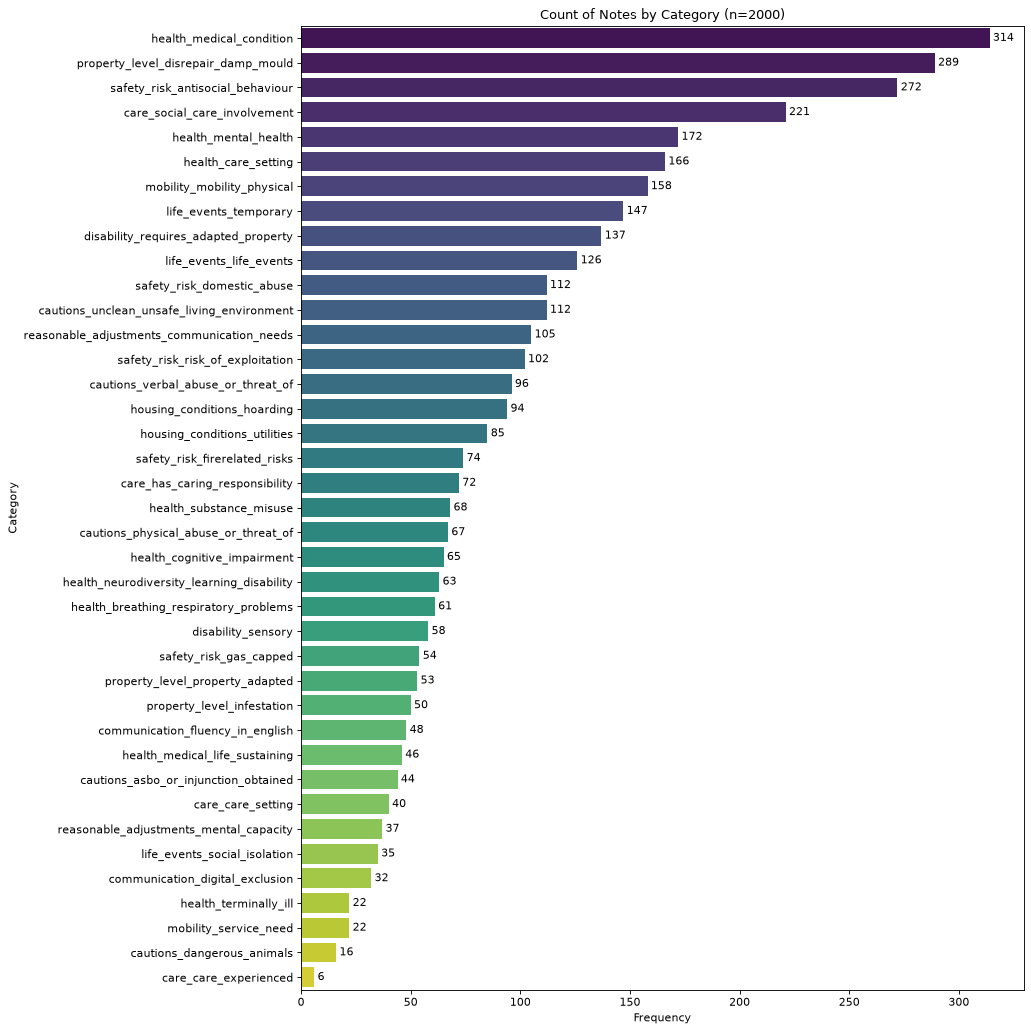

In [14]:
(irlbl_df, summary, ax) = analyze_category_distribution_from_dict(records, taxonomy, log_scale=False)

display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))
display(summary)
plt.show()

## Combine Low Prevalence Categories

In [15]:
MERGE_MAP = {
    "care_care_experienced": "life_events_life_events",
    "cautions_dangerous_animals": "safety_risk_antisocial_behaviour",
    "mobility_service_need": "mobility_mobility_physical",
    "health_medical_life_sustaining": "health_terminally_ill",
    "reasonable_adjustments_mental_capacity": "reasonable_adjustments_communication_needs",
    "life_events_social_isolation": "life_events_life_events",
}


In [16]:
taxonomy_v3 = taxonomy.copy()
taxonomy_v3['values_hint'] = taxonomy_v3['values_hint'].apply(ast.literal_eval)

# Merge regexes & values_hint to the new label
for old_label, new_label in MERGE_MAP.items():
    old_row = taxonomy_v3[taxonomy_v3['cat_label'] == old_label].iloc[0]
    new_idx = taxonomy_v3[taxonomy_v3['cat_label'] == new_label].index[0]

    old_regex = old_row['regex'].strip()
    new_regex = taxonomy_v3.at[new_idx, 'regex'].strip()
    taxonomy_v3.at[new_idx, 'regex'] = f"(?:{old_regex})|(?:{new_regex})"
    print(f"Merged regex: '{old_label}' + '{new_label}' -> combined pattern on '{new_label}' row")

    old_values = old_row['values_hint']
    new_values = taxonomy_v3.at[new_idx, 'values_hint']
    taxonomy_v3.at[new_idx, 'values_hint'] = new_values + old_values
    print(f"Merged value_hint: '{old_values}' + '{new_values}' -> combined on '{new_label}' row")


# Drop old labels & save
labels_to_drop = set(MERGE_MAP.keys())
taxonomy_v3 = taxonomy_v3[~taxonomy_v3['cat_label'].isin(labels_to_drop)].reset_index(drop=True)
taxonomy_v3.to_csv(Config.TAXONOMY_V3_PATH, index=False)

Merged regex: 'care_care_experienced' + 'life_events_life_events' -> combined pattern on 'life_events_life_events' row
Merged value_hint: '['Care leaver', 'Care experienced (under 25)']' + '['Ex service personnel', 'In prison', 'Left prison']' -> combined on 'life_events_life_events' row
Merged regex: 'cautions_dangerous_animals' + 'safety_risk_antisocial_behaviour' -> combined pattern on 'safety_risk_antisocial_behaviour' row
Merged value_hint: '['Dog', 'Reptile', 'Other']' + '['Perpetrator of harassment', 'Victim of harassment', 'Perpetrator of hate crime', 'Victim of hate crime']' -> combined on 'safety_risk_antisocial_behaviour' row
Merged regex: 'mobility_service_need' + 'mobility_mobility_physical' -> combined pattern on 'mobility_mobility_physical' row
Merged value_hint: '['Unable to answer door', 'Allow time to answer door', 'Prepayment Meter - can’t access', 'Personal Emergency Evaculation Plan (PEEP)']' + '['Frail', 'History of falls', 'Limited mobility: Zimmer frame', 'Limit

In [ ]:
records_v2 = []

# Loop through and reokace labels
for record in records:
    new_record = record.copy()
    for ann in new_record.get("needs", []):
        old_label = ann['label']
        if old_label in labels_to_drop:
            new_label = MERGE_MAP.get(old_label)
            ann['label'] = new_label
            print(f"Replaced label '{old_label}' with '{new_label}' in note {new_record['id']}.")
    records_v2.append(new_record)

Replaced label 'life_events_social_isolation' with 'life_events_life_events' in note d02ee213-1785-1603-e09f-e518b5a8954d.
Replaced label 'life_events_social_isolation' with 'life_events_life_events' in note d02ee213-1785-1603-e09f-e518b5a8954d.
Replaced label 'care_care_experienced' with 'life_events_life_events' in note ea4dfca4-2217-d79a-1006-237e50da9a6e.
Replaced label 'care_care_experienced' with 'life_events_life_events' in note c3c542ef-c255-b431-78df-1a85e12fc2a5.
Replaced label 'life_events_social_isolation' with 'life_events_life_events' in note 78548da4-ee06-4dc0-907c-de6b18422a06.
Replaced label 'mobility_service_need' with 'mobility_mobility_physical' in note 7bb4875e-96e1-47e0-94bb-512317b945a5.
Replaced label 'reasonable_adjustments_mental_capacity' with 'reasonable_adjustments_communication_needs' in note 5c4a7f84-d8d5-f17a-8ebf-7fcb3df260ba.
Replaced label 'health_medical_life_sustaining' with 'health_terminally_ill' in note 6e59bfef-6511-085c-df46-968a4daf411a.
Repla

,label,frequency,IRLbl
0,health_medical_condition,314,1.000000
1,property_level_disrepair_damp_mould,289,1.086505
2,safety_risk_antisocial_behaviour,283,1.109541
3,care_social_care_involvement,221,1.420814
4,health_mental_health,172,1.825581
5,mobility_mobility_physical,172,1.825581
6,health_care_setting,166,1.891566
7,life_events_life_events,161,1.950311
8,life_events_temporary,147,2.136054
9,reasonable_adjustments_communication_needs,139,2.258993


,Metric,Value
0,MeanIR,3.94
1,MaxIR,9.81
2,CVIR,0.55


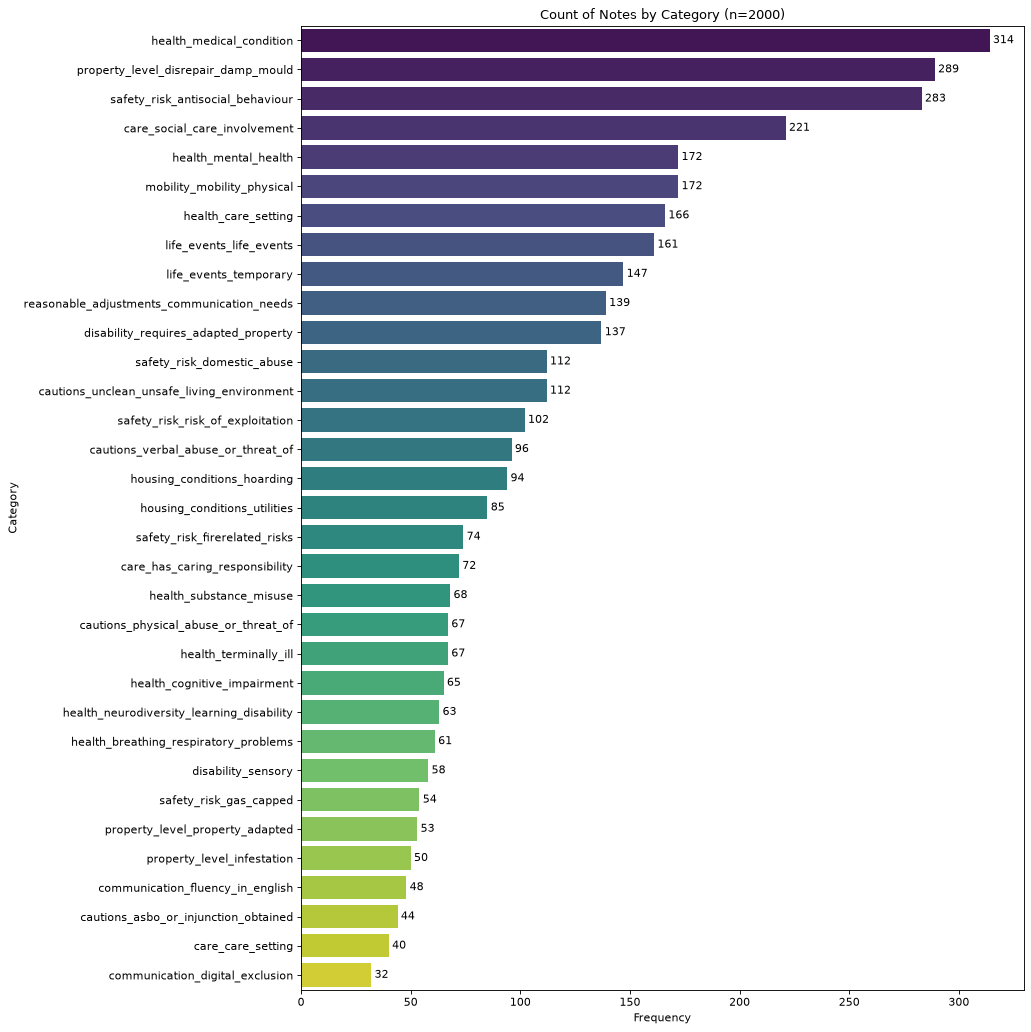

In [18]:
(irlbl_df, summary, ax) = analyze_category_distribution_from_dict(records_v2, taxonomy_v3, log_scale=False)

display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))
display(summary)
plt.show()

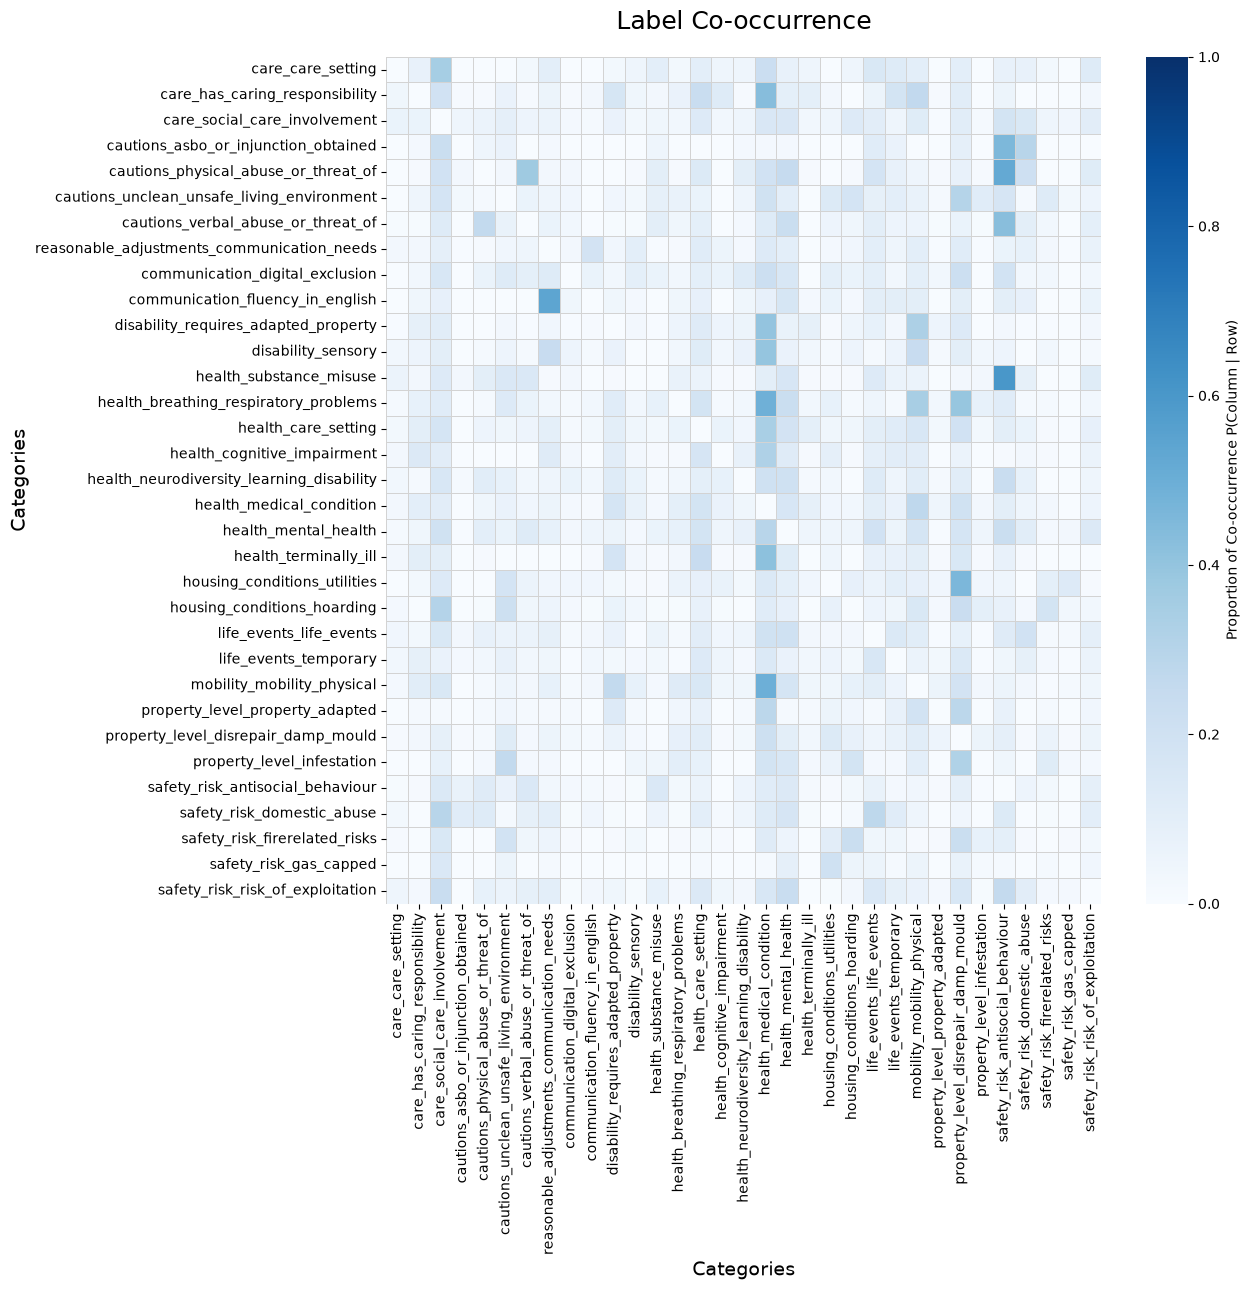

<Axes: title={'center': 'Label Co-occurrence'}, xlabel='Categories', ylabel='Categories'>

In [19]:
plot_cooccurrence_heatmap(records_v2, taxonomy_v3)

## Save as JSON

In [20]:
# Dump all
with open(Config.OUTPUT_PATH, "w", encoding='utf-8') as f:
    json.dump(records_v2, f, indent=4, default=str)


## Convert to Doc Level

In [21]:
label2id = {label: i for i, label in enumerate(Config.CAT_LABELS)}
id2label = {i: label for i, label in enumerate(Config.CAT_LABELS)}

In [22]:
converted = []

for record in records_v2:
    # Extract all unique labels from the "needs" spans
    labels_present = set()
    for need in record.get("needs", []):
        label = need["label"]
        if label in label2id:
            labels_present.add(label)
    
    # Create multi-hot vector
    multi_hot = [0] * len(Config.CAT_LABELS)
    for label in labels_present:
        multi_hot[label2id[label]] = 1
    
    converted.append({
        "id": record['id'],
        "text": record["text"],
        "labels": multi_hot,
        "label_names": list(labels_present)  # Keep for debugging
    })

In [25]:
converted[1]

{'id': '685524bb-94d4-4f08-8669-0e78df744c0c',
 'text': '[Category: tenureManagement] Welfare check and tenancy audit completed I visited the tenant in his property following his request for me to come over and assess the toilet in his property. I used the opportunity to complete a tenancy audit and I observed that he is a hoarder with so many items in nearly all the rooms. The toilet seat has broken and the toilet is as dark as charcoal.',
 'labels': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  0],
 'label_names': ['housing_conditions_hoarding',
  'cautions_unclean_unsafe_living_environment',
  'property_level_disrepair_damp_mould']}

In [23]:

# Save converted data
with open(Config.OUTPUT_PATH_DOC_LEVEL, 'w', encoding='utf-8') as f:
    json.dump(converted, f, indent=4, ensure_ascii=False)